In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("telco_clean.csv")
print(df["TotalCharges"].dtype, df.isna().sum().sum())   # float64 0

float64 0


In [3]:
# df = pd.read_csv(r"C:\Telco\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv")  

LogisticRegression

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

X = df.drop(columns=["Churn"])
y = (df["Churn"] == "Yes").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

num = ["tenure", "MonthlyCharges", "TotalCharges"]
cat = [c for c in X.columns if c not in num]

pre = ColumnTransformer([
    ("num", StandardScaler(), num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat),
])

base = Pipeline([("pre", pre),
                 ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))])
base.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pre', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'`

In [5]:
from sklearn.metrics import classification_report, roc_auc_score

pred = base.predict(X_test)
proba = base.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.841501976284585


In [6]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "clf__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"],
}

lr_search = GridSearchCV(
    base, param_grid, cv=cv,
    scoring="roc_auc", n_jobs=-1)
lr_search.fit(X_train, y_train)

print(lr_search.best_params_)
print("Best CV ROC-AUC:", round(lr_search.best_score_, 4))

{'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best CV ROC-AUC: 0.8462


c:\Telco\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [7]:
best_lr = lr_search.best_estimator_
pred = best_lr.predict(X_test)
proba = best_lr.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8407992973210364


 RandomForestClassifier

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf = Pipeline([
    ("pre", pre),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=5,          # stops trees from memorizing the training data
        class_weight="balanced",
        random_state=42,
        n_jobs=-1)),
])
rf.fit(X_train, y_train)

pred = rf.predict(X_test)
proba = rf.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.54      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409

ROC-AUC: 0.8417112299465241


In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print("CV ROC-AUC:", scores.mean().round(4), "+/-", scores.std().round(4))

CV ROC-AUC: 0.8448 +/- 0.0089


In [10]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "clf__n_estimators": [200, 300, 500],
    "clf__max_depth": [None, 6, 10, 15],
    "clf__min_samples_leaf": [3, 5, 10, 20],
    "clf__max_features": ["sqrt", "log2", 0.3],
}

search = RandomizedSearchCV(
    rf, param_dist, n_iter=20, cv=cv,
    scoring="roc_auc", random_state=42, n_jobs=-1)
search.fit(X_train, y_train)

print(search.best_params_)
print("Best CV ROC-AUC:", search.best_score_.round(4))

{'clf__n_estimators': 200, 'clf__min_samples_leaf': 20, 'clf__max_features': 0.3, 'clf__max_depth': 6}
Best CV ROC-AUC: 0.8483


In [11]:
import pandas as pd

names = rf.named_steps["pre"].get_feature_names_out()
imp = pd.Series(rf.named_steps["clf"].feature_importances_, index=names)
print(imp.sort_values(ascending=False).head(10))

num__tenure                            0.126488
cat__Contract_Month-to-month           0.120474
num__TotalCharges                      0.103650
num__MonthlyCharges                    0.075837
cat__OnlineSecurity_No                 0.061113
cat__Contract_Two year                 0.058030
cat__TechSupport_No                    0.052225
cat__InternetService_Fiber optic       0.042384
cat__PaymentMethod_Electronic check    0.037248
cat__Contract_One year                 0.020191
dtype: float64


XGBoost

In [12]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [13]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

spw = (y_train == 0).sum() / (y_train == 1).sum()   # ~2.77, handles imbalance
print("scale_pos_weight:", round(spw, 2))

xgb = Pipeline([
    ("pre", pre),
    ("clf", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,              # shallow trees, since this dataset is small
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=spw,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1)),
])
xgb.fit(X_train, y_train)

pred = xgb.predict(X_test)
proba = xgb.predict_proba(X_test)[:, 1]
print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba)) 

scale_pos_weight: 2.77
              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1035
           1       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

ROC-AUC: 0.8440143119171252


In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print("CV ROC-AUC:", scores.mean().round(4), "+/-", scores.std().round(4))

CV ROC-AUC: 0.8472 +/- 0.0113


In [15]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "clf__n_estimators": [100, 200, 300, 500],
    "clf__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "clf__max_depth": [2, 3, 4, 5],
    "clf__min_child_weight": [1, 3, 5, 10],
    "clf__subsample": [0.7, 0.8, 1.0],
    "clf__colsample_bytree": [0.5, 0.7, 0.8, 1.0],
    "clf__reg_lambda": [1, 5, 10],
}

xgb_search = RandomizedSearchCV(
    xgb, param_dist, n_iter=30, cv=cv,
    scoring="roc_auc", random_state=42, n_jobs=-1)
xgb_search.fit(X_train, y_train)

print(xgb_search.best_params_)
print("Best CV ROC-AUC:", round(xgb_search.best_score_, 4))

{'clf__subsample': 0.8, 'clf__reg_lambda': 5, 'clf__n_estimators': 200, 'clf__min_child_weight': 3, 'clf__max_depth': 3, 'clf__learning_rate': 0.03, 'clf__colsample_bytree': 0.5}
Best CV ROC-AUC: 0.8502


In [16]:
best_xgb = xgb_search.best_estimator_
proba = best_xgb.predict_proba(X_test)[:, 1]
pred = best_xgb.predict(X_test)
print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC: 0.8475134981528842


In [17]:
from sklearn.metrics import classification_report, roc_auc_score

# Get churn probabilities
y_prob = xgb_search.best_estimator_.predict_proba(X_test)[:, 1]

# Apply 0.3 threshold
THRESHOLD = 0.3
y_pred = (y_prob >= THRESHOLD).astype(int)

# Classification report
print(classification_report(y_test, y_pred))

# ROC-AUC
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.95      0.57      0.71      1035
           1       0.44      0.92      0.59       374

    accuracy                           0.66      1409
   macro avg       0.69      0.74      0.65      1409
weighted avg       0.81      0.66      0.68      1409

ROC-AUC: 0.8475134981528842


In [18]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
import numpy as np

final_xgb = xgb_search.best_estimator_

cv_proba = cross_val_predict(final_xgb, X_train, y_train, cv=cv,
                             method="predict_proba")[:, 1]

prec, rec, thr = precision_recall_curve(y_train, cv_proba)
f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)

best_thr = thr[np.argmax(f1)]
print("Best-F1 threshold:", round(best_thr, 3))
print("F1 at that threshold:", round(f1.max(), 3))

Best-F1 threshold: 0.602
F1 at that threshold: 0.64


In [19]:
import pandas as pd

rows = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    p = (cv_proba >= t).astype(int)
    tp = ((p == 1) & (y_train == 1)).sum()
    rows.append({
        "threshold": t,
        "precision": tp / max(p.sum(), 1),
        "recall": tp / (y_train == 1).sum(),
        "flagged_%": p.mean() * 100,
    })
print(pd.DataFrame(rows).round(3))

   threshold  precision  recall  flagged_%
0        0.3      0.433   0.913     56.017
1        0.4      0.476   0.872     48.651
2        0.5      0.518   0.810     41.480
3        0.6      0.584   0.706     32.109
4        0.7      0.656   0.581     23.518


In [20]:
proba = final_xgb.predict_proba(X_test)[:, 1]
pred = (proba >= best_thr).astype(int)
print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.89      0.81      0.85      1035
           1       0.58      0.73      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.78      0.79      1409

ROC-AUC: 0.8475134981528842


In [21]:
import joblib
joblib.dump({"model": final_xgb, "threshold": float(best_thr)}, "churn_xgb.joblib")

['churn_xgb.joblib']

In [22]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [23]:
import shap
import matplotlib.pyplot as plt

pre_fit = final_xgb.named_steps["pre"]
clf = final_xgb.named_steps["clf"]

X_test_t = pre_fit.transform(X_test)
if hasattr(X_test_t, "toarray"):          # in case the output is sparse
    X_test_t = X_test_t.toarray()

feature_names = pre_fit.get_feature_names_out()
X_test_df = pd.DataFrame(X_test_t, columns=feature_names)

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_df)

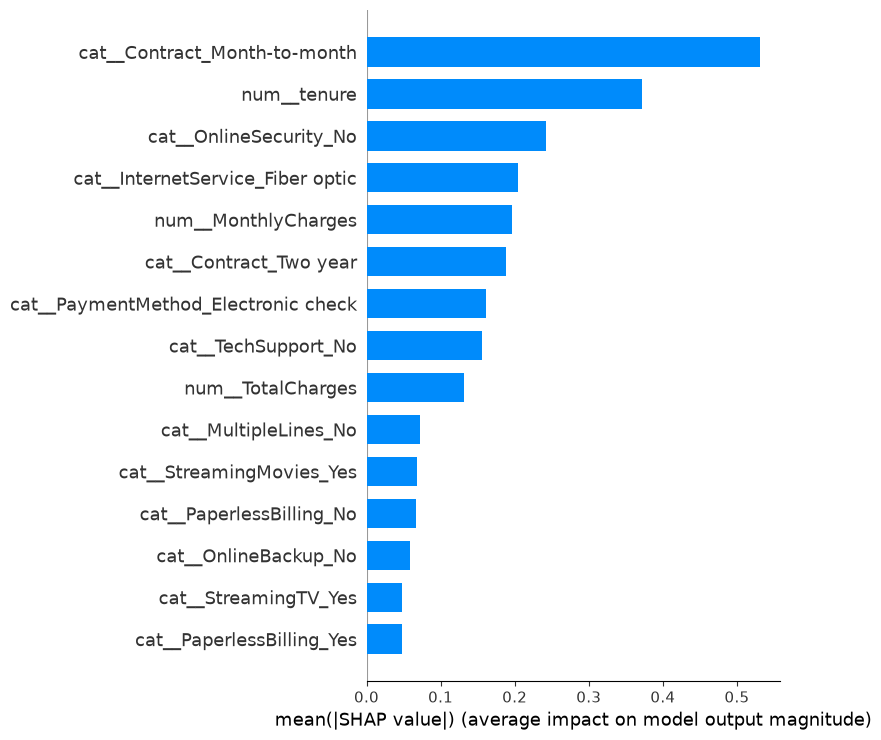

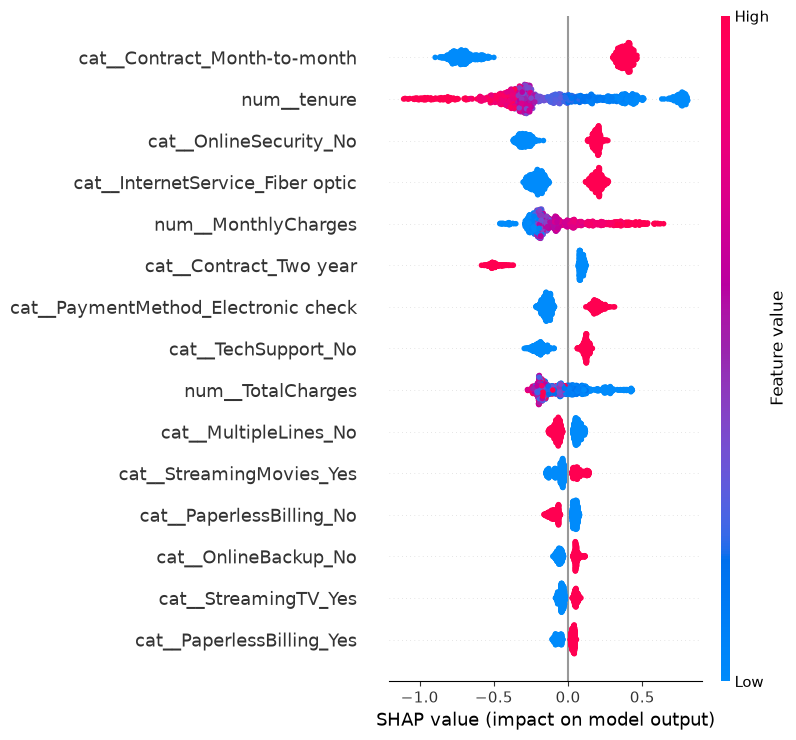

In [24]:
# Top features by average impact
shap.summary_plot(shap_values, X_test_df, plot_type="bar", max_display=15)

# Direction of impact: high or low values push churn up or down
shap.summary_plot(shap_values, X_test_df, max_display=15)

In [25]:
import joblib
joblib.dump({"model": final_xgb, "threshold": float(best_thr)}, "churn_xgb.joblib")

['churn_xgb.joblib']